# Intelligent Methods for Resilience: Household Energy Shifting in DK1

#### Problem
The DK1 electricity system is increasingly challenged by the combination of rising electricity demand and a growing share of variable renewable energy. Electrification of transport and heating increases overall consumption, while wind and solar introduce greater temporal variability in supply. This creates periods where the system experiences peak pressure, defined by high demand relative to available supply, which can lead to congestion, inefficient use of renewable energy, and reduced system stability. At the same time, a portion of household electricity consumption is inherently flexible, meaning it can be shifted in time without significant loss of utility. The core challenge is therefore not only technological, but behavioral and informational: **how to activate this latent flexibility in a way that meaningfully supports system resilience.**

#### Question
**How can price forecasting and explainable energy recommendations be used to reduce peak pressure and improve resilience in the DK1 electricity system?**

#### Method
The project combines XGBoost-based electricity price forecasting with uncertainty intervals and explainable AI methods, and translates these forecasts into actionable household recommendations, where behavior is modelled through a 120-hour rolling shifting heuristic to evaluate the resulting resilience impact.

#### Underlying idea
The central idea is that price signals can act as a proxy for grid stress, and that translating these signals into clear, explainable recommendations enables households to shift flexible consumption away from high-pressure periods. This includes activities such as electric vehicle charging and the use of appliances like dishwashers, washing machines, and dryers, which can be delayed or advanced in time. While the impact of a single household is small, coordinated shifts across many households can aggregate into a measurable system-level effect. **The approach therefore tests whether many small, local decisions, guided by intelligent methods, can collectively improve system resilience.**


## Introduction: Defining Resilience and the Current Grid State in DK1

To evaluate whether the project improves resilience, we first need to describe the current state of the DK1 electricity grid. In this project, the most direct observable signal of grid state is electricity consumption. When consumption is high, more electricity has to be transported through the network at the same time, which increases operational pressure and makes balancing the system more difficult.

Because we do not observe transformer limits or line-level congestion directly, we use historical system consumption as a transparent proxy for stress. The first figure below plots the full historic hourly DK1 consumption series in grey and marks the historical 95th percentile with a red horizontal line. Hours around and above this threshold are treated as peak-load periods. These peaks matter because they reflect moments where the grid operates closer to its upper normal range, increasing the risk of congestion, higher balancing pressure, and faster wear on network assets.


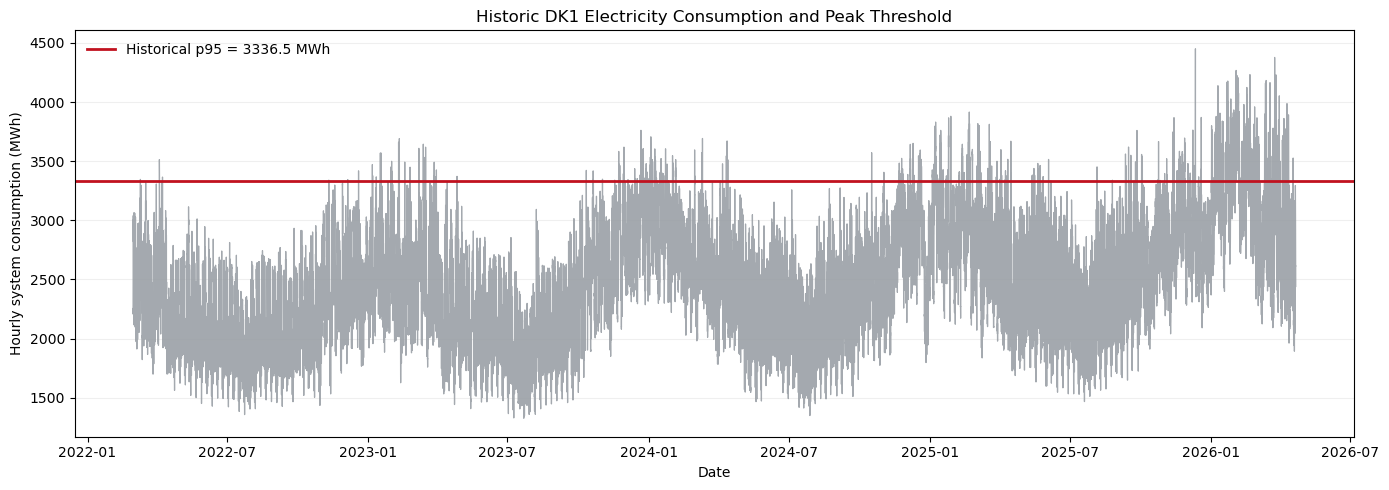

In [2]:
from src.analysis.energy_congestion_analysis import (
    build_grid_state_summary,
    plot_historic_consumption_with_p95,
)

grid_state = build_grid_state_summary()
historic_consumption_figure, _ = plot_historic_consumption_with_p95(grid_state)


The historic series shows that high-load periods are recurring rather than isolated events. It also illustrates how the consumption is increasing over the years, causing more stress hours. To understand the historic consumption trend over the years, the next figure aggregates consumption to monthly totals across the observed years and then counts how many hours in each year exceed the historical 95th percentile.

The monthly bars make the longer-run demand development easier to read than the raw hourly series. The yearly peak-hour bar chart then serves as a compact snapshot of the current grid state: if total consumption and the number of peak hours both rise over time, the need for action that removes or shifts peak loads becomes more urgent.


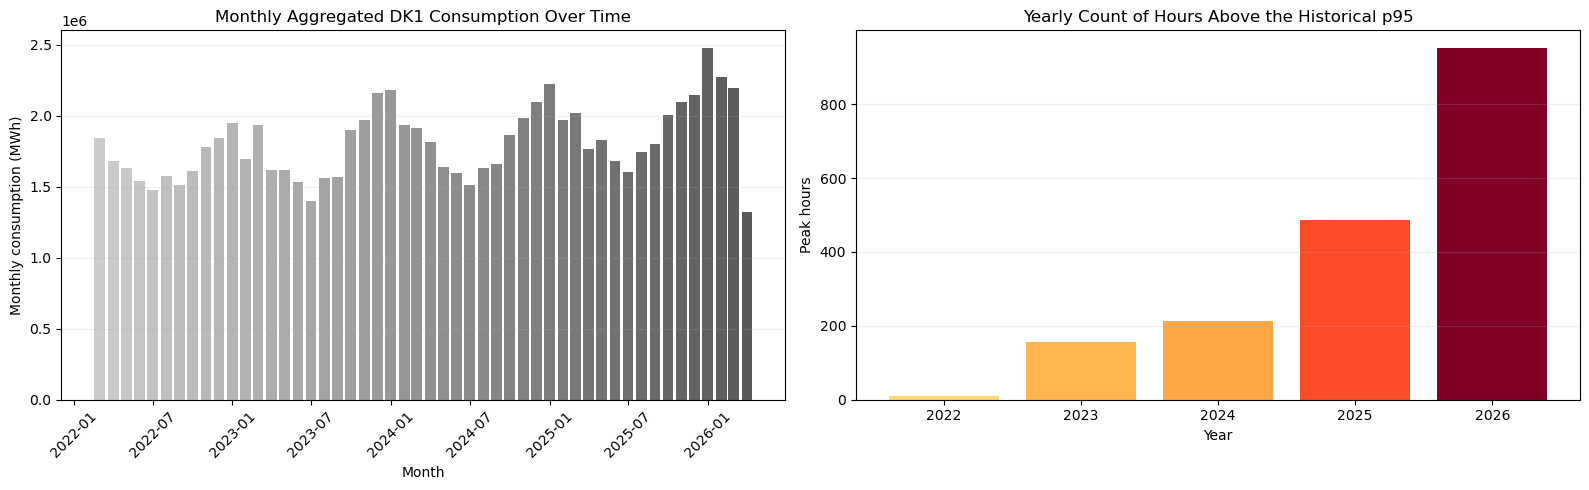

In [3]:
from src.analysis.energy_congestion_analysis import plot_consumption_trend_and_peak_hours

trend_and_peaks_figure, _ = plot_consumption_trend_and_peak_hours(grid_state)


The figures suggest that DK1 is not only characterised by recurring peak-load hours, but also by a broader upward development in electricity consumption over time. This strengthens the case for action: if demand continues to grow while peaks remain frequent, the grid becomes increasingly exposed to stress during already demanding hours. The resilience contribution of the project must therefore be understood as an attempt to improve the timing of consumption, shifting flexible demand away from periods where the system is already under pressure.

To do that in practice, households need more than a description of the current grid state. They need forward-looking signals that indicate when it is likely to be costly or beneficial to consume electricity. This is where forecasting enters the project: after defining the stress problem, the next step is to predict future electricity prices so they can be used as a decision signal for shifting demand.


## Forecast Analysis: Predicting hourly electricity prices 120 hours ahead


The forecast is the central analytical element of the project. Energy shifting is a timing decision: a household can only postpone EV charging, laundry, dishwashing, or heating if it has a credible signal that another hour in the near future will be cheaper or less stressful for the system. In DK1, prices are especially useful because they summarize market scarcity, demand, wind and solar production, interconnector conditions, and other system pressures in one observable hourly signal.

The purpose of the forecast is therefore broader than minimizing prediction error. It creates the forward-looking price profile that the dashboard later turns into recommendations. A good forecast should identify expensive periods, cheap windows, and the uncertainty around those signals, because the recommendation layer should be more confident when the predicted price difference is large and more cautious when the model has historically been noisy at that horizon.


### Data Acquisition: Prices, consumption, weather actuals, and weather forecasts
To forecast DK1 electricity prices, we first need data that describes the price itself and the conditions that influence it. We collect day-ahead prices, observed weather, previous-run weather forecasts, and consumption data. The raw files are saved in `data/`. The consumption data is later used to measure grid stress and simulate load shifting..
Data is collected from two public APIs — Energi Data Service for electricity prices and consumption, and Open-Meteo for historical weather actuals and NWP forecasts.

The main data sources are:

- `data/day_ahead_prices_dk1_raw.csv`: hourly day-ahead prices for DK1 from Energi Data Service.
- `data/consumption_dk1_raw.csv`: DK1 electricity consumption used later to measure grid stress and simulate load shifting.
- `data/weather_actuals_raw.csv`: historical weather observations for the DK1 weather location.
- `data/weather_forecasts_raw.csv`: previous-run weather forecasts from Open-Meteo, used to estimate forecast errors.

All raw datasets can be collected with one call:

In [ ]:
from src.data.data_collection import fetch_all

results = fetch_all(start="2021-01-01", end="2026-04-28", price_area="DK1")

As a quick check, we plot prices and actual weather for the same period. This helps confirm that the scraped time series line up and that the weather variables are relevant for price forecasting.

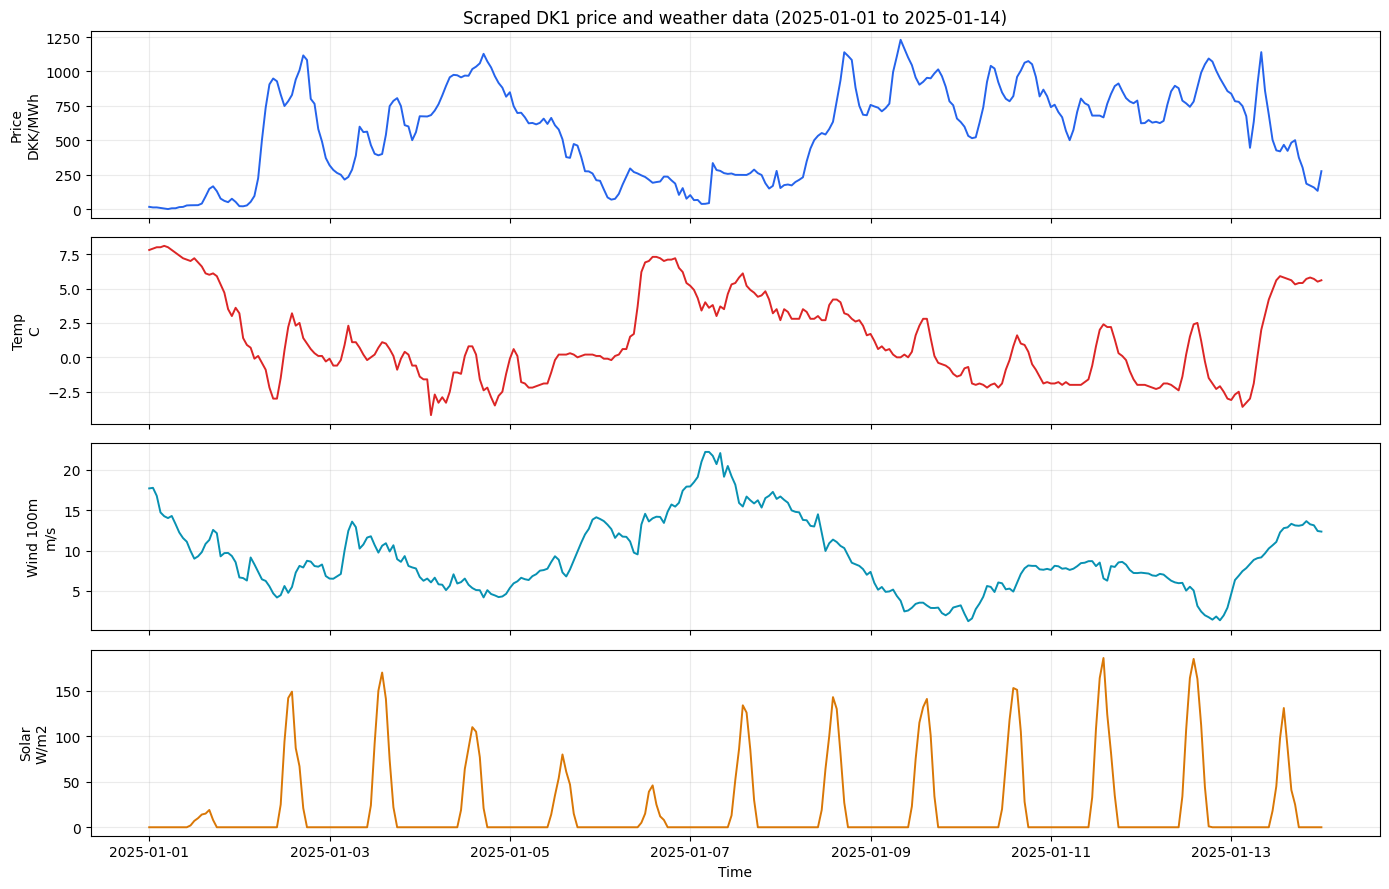

In [1]:
from src.analysis.forecast_analysis import plot_raw_price_and_weather

fig = plot_raw_price_and_weather(start="2025-01-01", end="2025-01-14")

The plot suggests the weather variables are useful predictors of DK1 electricity prices. Price movements appear to line up with changes in wind, temperature, and solar conditions: when wind drops or solar output is low, prices often rise, while stronger wind periods are associated with lower prices. Temperature also seems relevant, as colder periods may increase demand and contribute to higher prices. Overall, the visible movement between price and weather supports the idea that these variables contain predictive information for electricity prices.

### Data Processing: Building a leakage-safe forecast matrix
Before the data can be used for prediction, it must be transformed into the same format the model will see in practice. The key issue is weather data: at forecast time, future realised weather is not known. The model can only rely on weather forecasts.

Real previous-run weather forecasts are only available from 2025 onwards. This period is therefore used to estimate typical forecast errors. These errors are then applied to historical realised weather data to generate forecast-like weather inputs for the full historical period.

This step is important because using historical actual weather directly as a future predictor would create data leakage. The model would then learn from information that would not have been available at the time of making a real forecast. By replacing future actual weather with forecast-like inputs, the dataset better reflects the real forecasting situation.The estimated error distributions are saved in
- `data/weather_error_distributions.csv`:

The plot below shows how forecast error evolves as the horizon increases. To incorporate this behaviour into the modelling pipeline, the processing script (`src/data/data_processing.py`) constructs a forecast matrix with 120 rows for each issue time, corresponding to horizons from 1 to 120 hours ahead.

Each row represents the information available at the issue time and includes forecast-based weather variables, calendar features, and price lags that would be known in real time. To realistically simulate weather forecasts, noise is added to the realised weather observations. This noise is drawn from the horizon-specific error distributions visualised below, meaning that for each forecast horizon, the magnitude and spread of the noise reflect the empirically observed forecast uncertainty. As a result, short-horizon inputs remain close to the true values, while longer-horizon inputs exhibit increasing variability.

The target variable is the realised day-ahead electricity price at the corresponding target time.

This results in a leakage-safe forecast matrix that closely mirrors the information structure of the production dashboard: all features are constructed using only information available at the issue time, while also embedding realistic forecast uncertainty that grows with the prediction horizon.

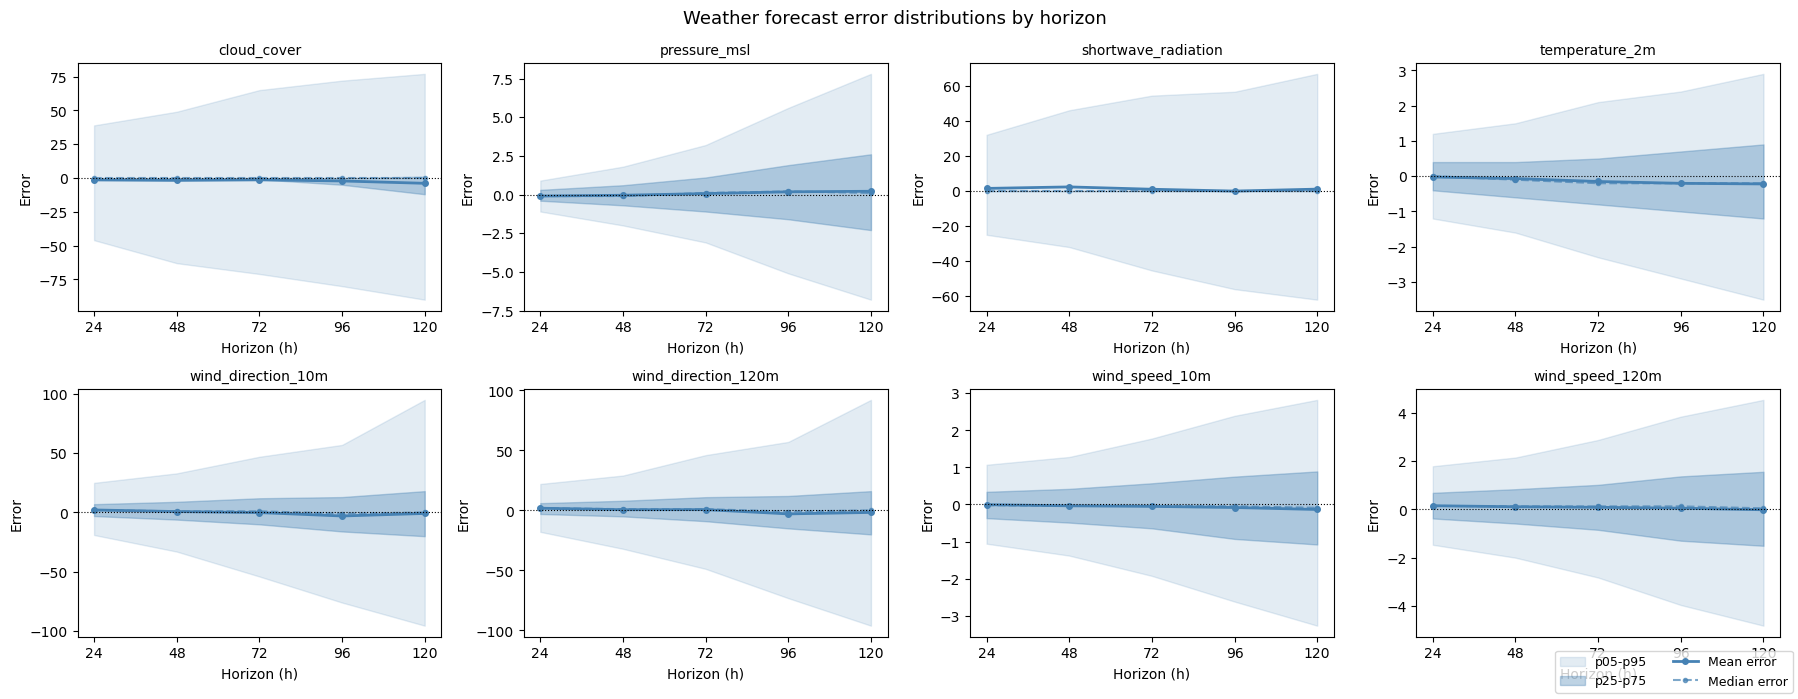

In [10]:
from src.data.data_processing import plot_weather_error_distributions

plot_weather_error_distributions()

The figure shows the distribution of forecast errors for key weather variables across increasing forecast horizons (24 to 120 hours). For each variable, the mean and median errors remain close to zero, while the spread of the distribution, captured by the percentile bands, widens significantly as the horizon increases.

This indicates that the weather forecasts are largely unbiased, but become progressively more uncertain further into the future. In particular, variables such as cloud cover, shortwave radiation, and wind direction exhibit substantial increases in variability at longer horizons, while temperature and wind speed show more moderate but still noticeable growth in uncertainty.

This pattern is important for the electricity price forecasting task. Weather variables are key drivers of both electricity demand (e.g. temperature) and renewable generation (e.g. wind and solar). As forecast uncertainty increases with horizon, the inputs to the price model become less precise, which directly propagates into greater uncertainty in predicted electricity prices.

**From a modelling perspective, this has two implications.** First, it justifies the use of a flexible model such as XGBoost, which can capture nonlinear relationships even under noisy inputs. Second, it motivates the inclusion of forecast intervals rather than relying solely on point predictions, as uncertainty is an inherent and increasing feature of the data.

In the plots below, we can see how the forecast error is applied across different forecast horizons.

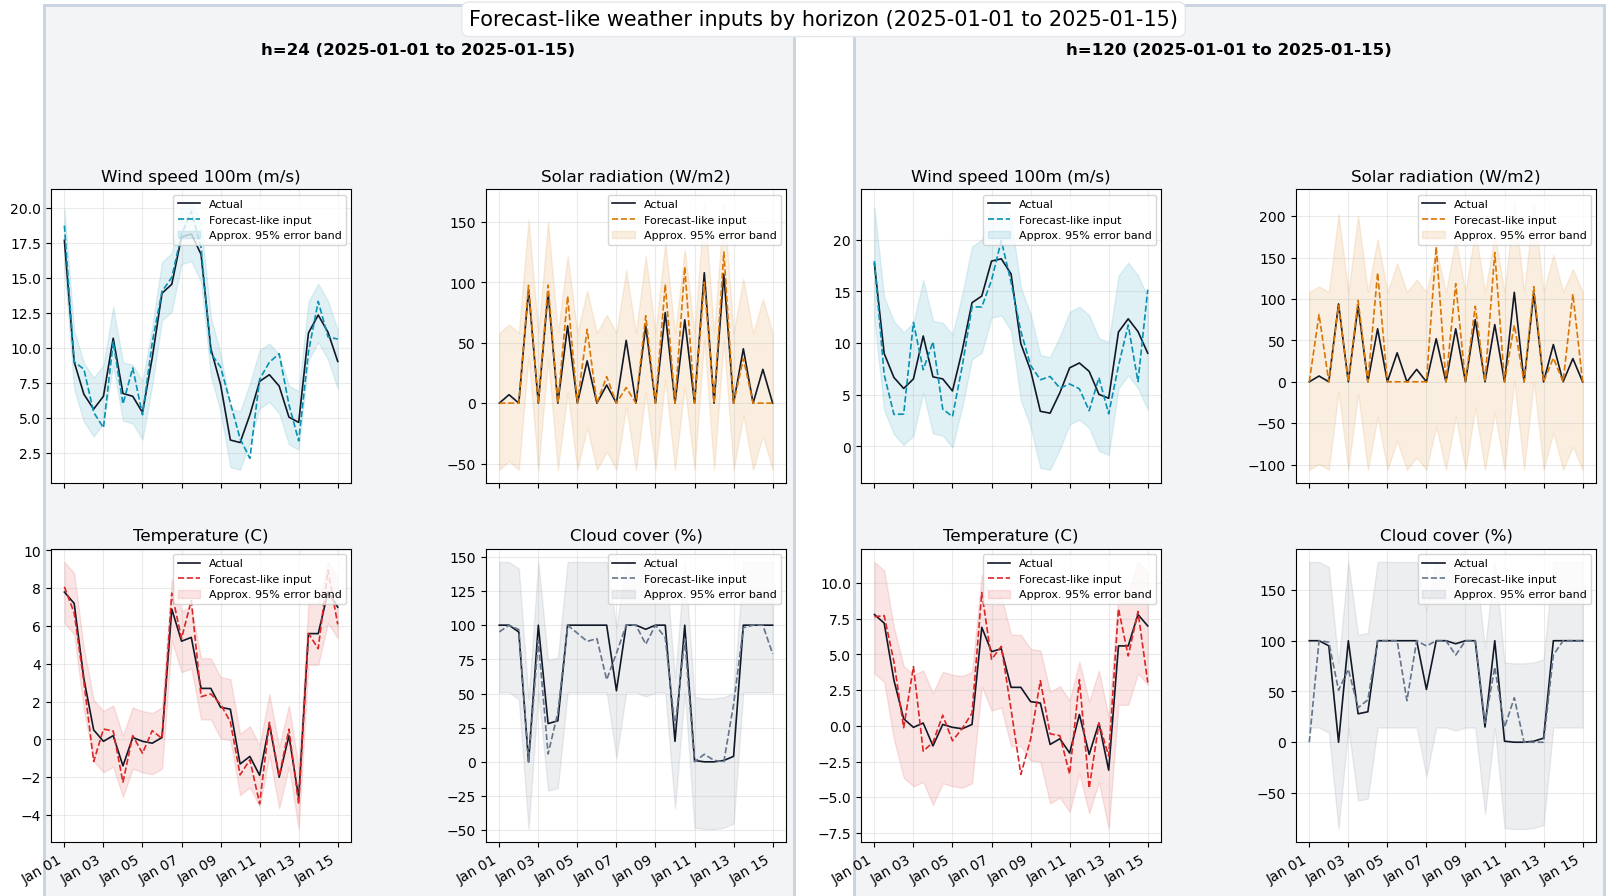

In [1]:
from src.analysis.forecast_analysis import plot_weather_forecast_grid

fig = plot_weather_forecast_grid(horizon_hours=[24, 120])



The weather plots show why the processing step is necessary. At a 24-hour horizon, the generated forecast-like weather variables generally follow the realised weather closely. At a 120-hour horizon, the deviations and uncertainty bands are wider. This is expected: longer weather forecasts are harder, and that uncertainty can propagate into electricity-price forecasts.

The implication for the recommender system is practical. A five-day forecast can still be valuable, but recommendations based on later horizons should be interpreted with more caution than recommendations based on the next few hours. This is one reason the forecast section evaluates both point accuracy and residual uncertainty by horizon.


Next examine which variables appear most informative for predicting future DK1 prices. For this purpose, we calculate the Pearson correlation between each feature and the target variable at the 120-hour horizon. This gives an initial indication of the strength and direction of the linear relationship between the input variables and the future price before fitting the forecasting models.

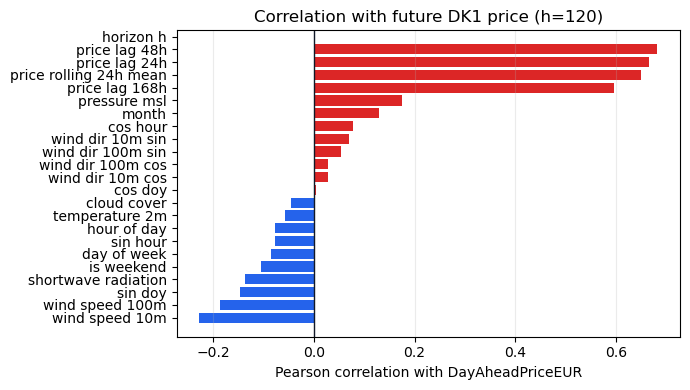

In [ ]:
from src.analysis.forecast_analysis import plot_weather_price_correlation, plot_price_history_with_5day_forecast

fig = plot_weather_price_correlation(correlation_horizon=120)


The correlation plot is not a causal analysis but a sanity check — it confirms that the weather forecast variables and lagged price features carry statistical information about the future price target before any model is trained. Some relationships are likely nonlinear or context-dependent. Higher wind production, for example, tends to push prices down by increasing renewable supply, but the actual effect depends on demand, interconnector flows, and overall market conditions at the time. The variables shown here are exactly the features passed to the XGBoost model, and the full feature matrix is saved as`data/model_dataset.parquet`:

### XGBoost Forecasting Model

The forecasting model is implemented in `src/models/XG_Boost_full_Res.py`. The script trains five separate XGBoost regression models, one for each forecast day:

- Day 1: horizons 1-24 hours ahead.
- Day 2: horizons 25-48 hours ahead.
- Day 3: horizons 49-72 hours ahead.
- Day 4: horizons 73-96 hours ahead.
- Day 5: horizons 97-120 hours ahead.

This design is useful because short-horizon and long-horizon forecasts have different error structures. The next few hours are usually more anchored by recent prices and near-term weather forecasts, while later horizons are more uncertain and depend more on broader calendar and weather-pattern information. Splitting the model by forecast day lets each XGBoost regressor specialize in one part of the 120-hour horizon.

XGBoost is a good choice for this project because electricity prices are tabular, nonlinear, and interaction-heavy. Gradient-boosted trees can capture threshold effects, such as very low wind or peak-hour demand, without requiring all interactions to be manually specified. The method also works well with mixed calendar, lag, and weather features, requires little feature scaling, and can later be inspected using feature importance and SHAP. Finally, the model is fast enough to retrain and evaluate with walk-forward validation, which is important for a time-series forecasting problem. A Temporal Fusion Transformer was also tested, but it performed poorly compared with XGBoost. This is likely because the available dataset is relatively limited and the forecasting problem is mainly based on structured tabular features.

Validation is performed with an expanding walk-forward split. The first 12 months are used for training, the next 3 months are used for testing, and the training window then expands forward. This preserves the time order of the data and produces out-of-sample residuals that can be used both for accuracy metrics and uncertainty estimation.
The model performance is evaluated using MAE, since it measures the average forecast error in the same unit as the electricity price. It is easy to interpret and less affected by extreme price spikes than RMSE, making it suitable for assessing typical forecast accuracy.

In the plot below, we can se how accurate the 5-day price forecasts are compared to the actual prices. 


In [26]:

fig = plot_price_history_with_5day_forecast(
    issue_time="2026-04-23 00:00",
    ctx_days=7,
    unit="dkk_kwh",
    show_actuals=True,
    show_uncertainty=False,
)


The plot shows the historical DK1 price followed by the 5-day XGBoost forecast. The model captures the overall trends reasonably well, including the daily price pattern, but smooths some of the largest spikes and sudden drops. Since the model is evaluated using MAE, the focus is on typical forecast accuracy rather than heavily penalizing rare extreme price movements. A more general analysis of the model performance can be seen below: 

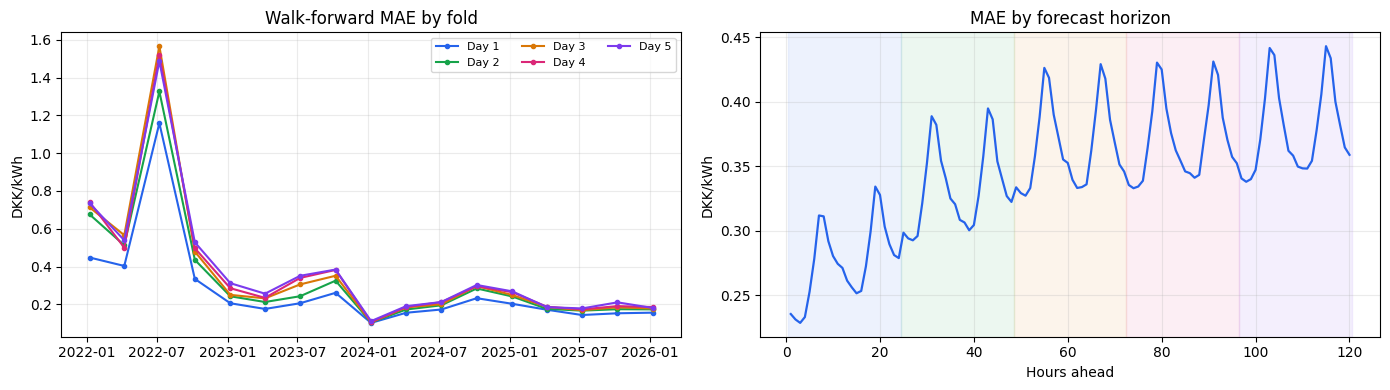

In [29]:
from src.analysis.forecast_analysis import plot_forecast_mae_summary

fig = plot_forecast_mae_summary(unit="dkk_kwh")


The first plot shows how the different forecast horizons perform over time. It is clear that all models are affected by the energy crisis period, where the MAE increases sharply. This is expected because electricity prices became much harder to predict during this period due to high volatility and sudden price spikes. Overall, the shorter forecast horizons perform better, with Day 1 generally having the lowest error, while the longer horizons tend to have higher MAE. Second, the horizon plot shows how error develops across the 120-hour forecast window. This is directly relevant for recommendations: a predicted saving tomorrow is usually a stronger signal than a similarly sized predicted saving five days ahead if the five-day residual spread is much larger.

The forecast does not need to be perfect to be useful. For household flexibility, the key question is whether the model can rank future hours well enough to identify cheaper and more expensive windows. However, the size of the forecast error determines how forcefully the dashboard should communicate a recommendation. Small expected savings inside a wide error band should be framed cautiously, while large savings that exceed historical uncertainty can support a stronger recommendation.


### Price Prediction Uncertainty: Residual-based forecast bands

The lecture material on prediction uncertainty emphasizes that a prediction should not be treated only as a single expected value. A future price is uncertain, so a decision-support system should also communicate the spread around the point forecast. In this project we estimate uncertainty from the walk-forward residuals, because those residuals measure how wrong the model was on data that was not used for fitting.

For each out-of-sample prediction we compute the signed residual

$$
e_h = \hat{y}_h - y_h,
$$

where $\hat{y}_h$ is the predicted price for horizon $h$ and $y_h$ is the realised price. We then group residuals by `horizon_h` and calculate a horizon-specific standard deviation, $\sigma_h$. The simple forecast band used here is

$$
\hat{y}_h \pm \sigma_h.
$$

The diagnostics below use residuals from 1 January 2023 onward. This keeps the uncertainty estimate focused on the post-energy-crisis market regime, rather than letting the extreme 2022 volatility dominate the current dashboard bands. The band should be interpreted as an empirical prediction-uncertainty measure, not as a guarantee that prices will fall inside the interval. 

Below we can see how the user will see it in their dashboard:


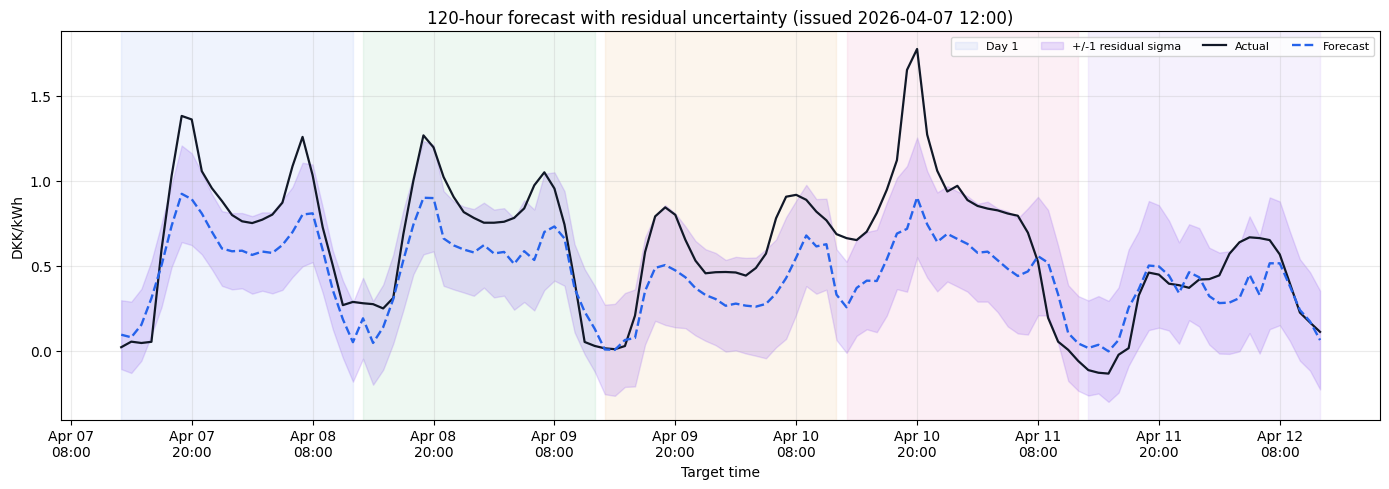

In [46]:
from src.analysis.forecast_analysis import (
    plot_price_history_with_5day_forecast,
    plot_single_forecast_with_uncertainty,
)

issue_time = "2026-04-23 00:00"

fig_context = plot_price_history_with_5day_forecast(
    issue_time=issue_time,
    ctx_days=7,
    unit="dkk_kwh",
    show_actuals=True,
    show_uncertainty=True,
)

fig_uncertainty = plot_single_forecast_with_uncertainty(
    issue_time=issue_time,
    unit="dkk_kwh",
)


The uncertainty bands show how uncertain the predictions are. In this case, the bands are quite wide, which indicates that the model is still relatively uncertain about the exact future price level. This is partly a natural result of the data format and the limited information available to the model. In a final product, with more data, better feature engineering, and further model development, the predictions would likely become more certain.

The uncertainty is still useful because it makes the forecast easier to interpret. Instead of only showing a single predicted price, the dashboard also shows how much confidence the model has in that prediction. If the predicted cheapest period is only slightly cheaper than the current price and the uncertainty band is wide, the user should treat the recommendation with caution. If the predicted price drop is larger and the uncertainty band is narrower, the recommendation to delay flexible consumption becomes more reliable.

This also gives the consumer more control. By seeing the uncertainty directly in the dashboard, they can decide how much trust to place in the prediction. In this way, the uncertainty does not make the forecast less useful. It helps communicate when the model’s advice should be trusted strongly, and when it should be seen as more uncertain.

## Explainable AI: SHAP and LIME for a decision-support forecast

The forecasting model produces a 120-hour price profile for DK1. The recommendation layer then translates that forecast profile into consumption advice: whether a household should consume energy now to avoid an expensive period or wait for a cheaper window. Explainable AI sits between these two steps. Its purpose is to analyse which input variables are driving the predicted prices and how. It is then fed into the LLM recommendation layer to make meaningfull and trustworthy reasoning.

In [ ]:
import joblib

from src.analysis.explainable_ai import (
    OUTPUT_DIR,
    make_dashboard_lime_summary,
    make_dashboard_shap_summary,
    plot_feature_importance,
    plot_lime_explanations,
    plot_shap_explanations,
)

final_models = joblib.load(OUTPUT_DIR / "final_day_models.joblib")



We start with XGBoost feature importance as a coarse global view. The model is split into five day-specific regressors, so the plot shows whether the short-horizon and long-horizon forecasts depend on similar drivers or whether the dominant predictors change across the 120-hour forecast window.


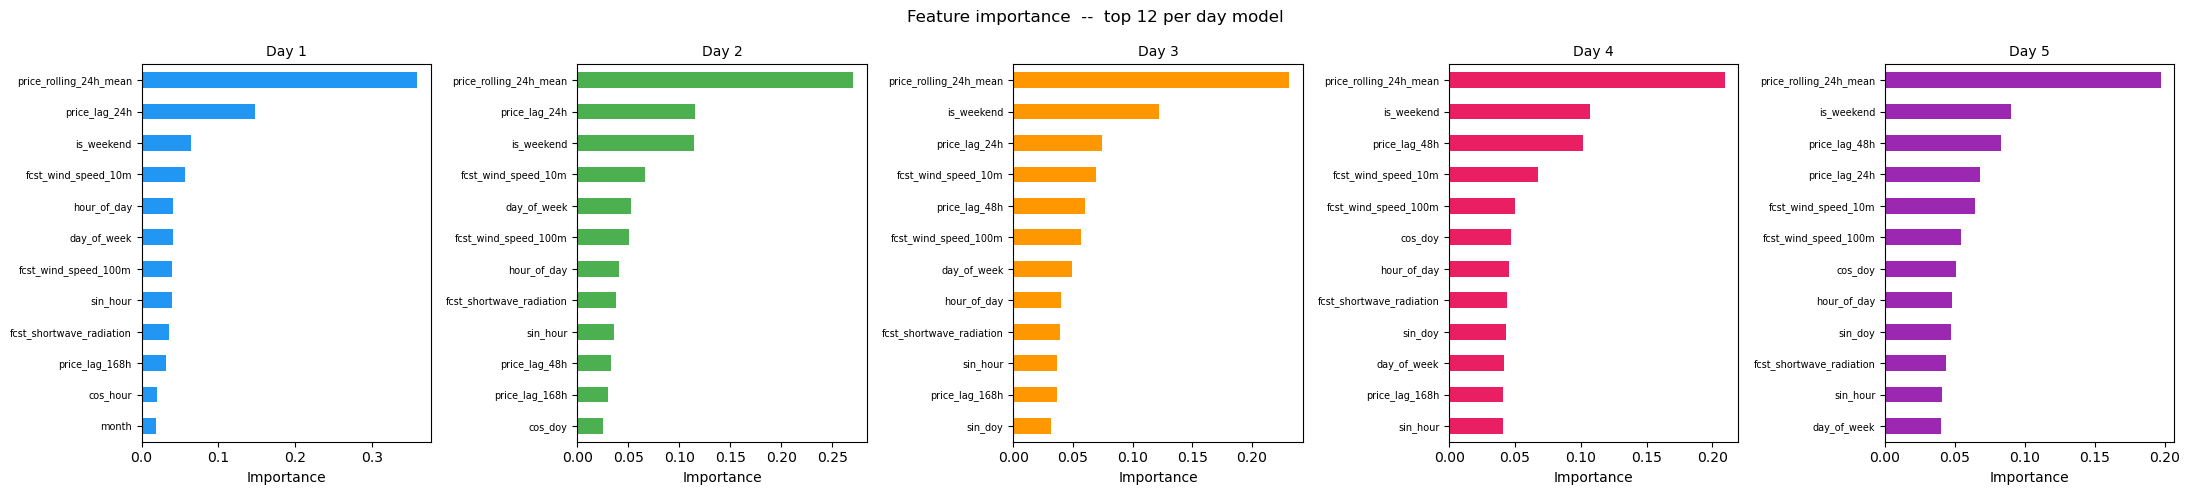

In [ ]:
plot_feature_importance(final_models)

Across all five day-specific models, the rolling 24-hour mean price is the most important feature by a large margin. This means that the forecast is anchored heavily in the recent price level: if prices have been high during the last day, the model tends to expect elevated prices to continue, and if prices have recently been low, the forecast is pulled downward. This is a plausible result for electricity price forecasting. Day-ahead prices are not random from hour to hour; they often move in regimes where fuel prices, wind conditions, demand, imports/exports, and market expectations keep prices elevated or depressed for several consecutive hours or days. The model therefore appears to learn a meaningful persistence effect rather than relying only on weather forecasts.

Weather variables, especially fcst_wind_speed_10m and fcst_wind_speed_100m, appear among the top predictors across the forecast window, but they have lower importance than recent price features. This suggests that weather forecasts refine the price forecast around a baseline mainly set by recent market behaviour.

There is also a visible horizon effect. For Day 1, the model relies strongly on price_lag_24h, meaning yesterday’s mean price is highly informative for the next 24 hours. From Day 3 onward, price lags such as price_lag_24h, price_lag_48h, and price_lag_168h become more visible. This makes intuitive sense: as the forecast horizon expands, the exact price level from yesterday becomes less directly useful, while weekly seasonality and broader price regimes become more relevant. The increasing role of is_weekend, day_of_week, and time-cycle variables also supports this interpretation.

Feature importance is useful as an entry point, but it does not show whether a feature pushes the forecast up or down. It can also blur correlated drivers. We therefore use SHAP as the main global explanation method. SHAP decomposes each forecast into additive feature contributions, which is useful when the dashboard recommends a timing decision and we want to understand why a cheap or expensive window appears in the forecast.

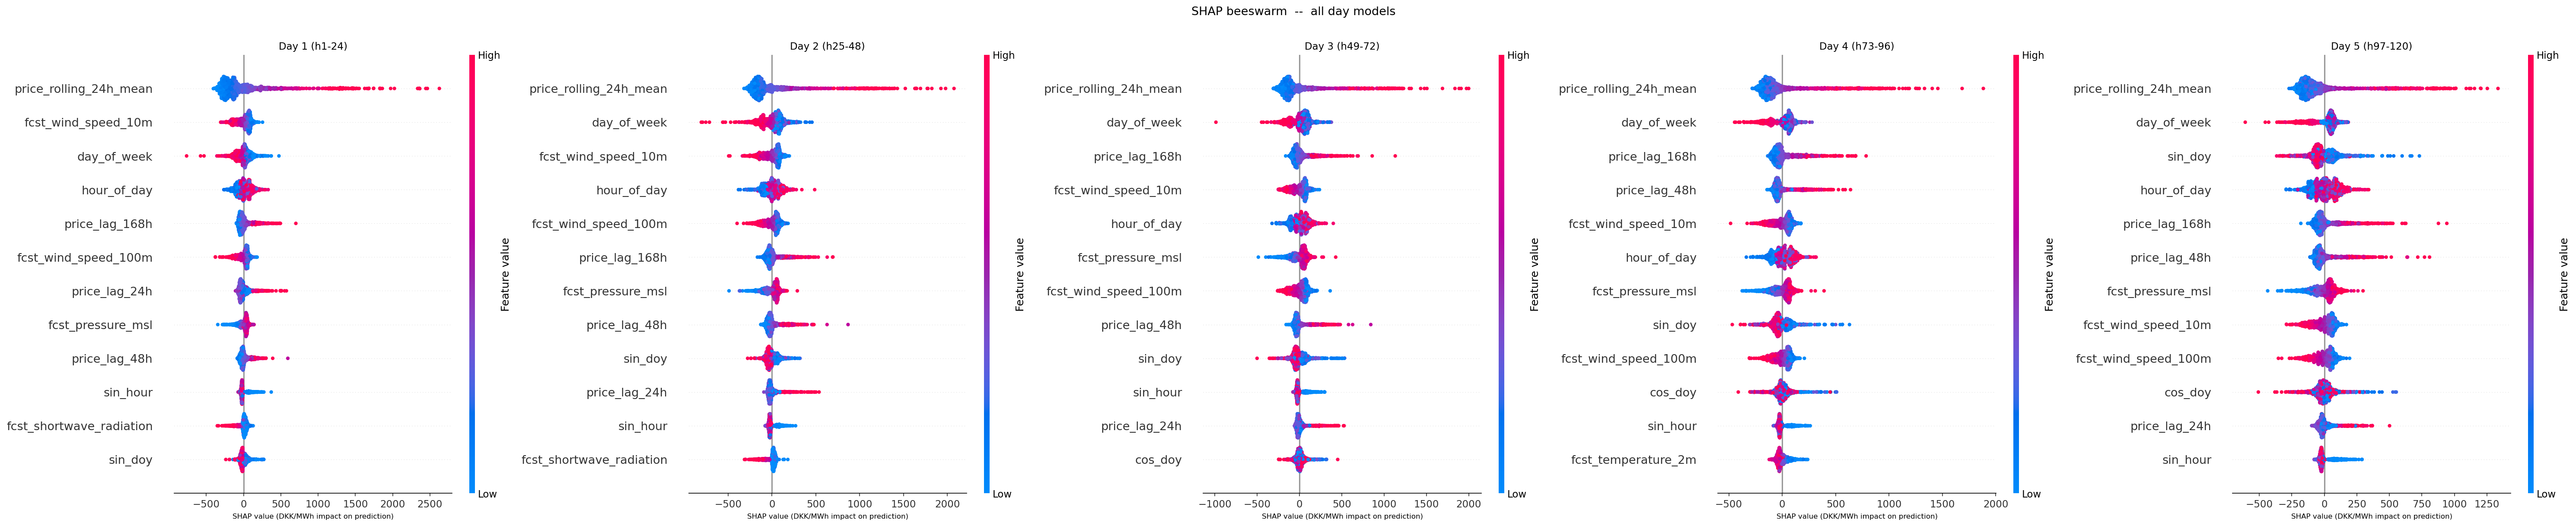

In [ ]:
plot_shap_explanations(width=1200)

The SHAP beeswarm plot gives a more detailed view of how the model uses each feature across many forecasts. Each point represents one forecasted hour, where the horizontal position shows whether the feature pushed the prediction up or down. The colour shows the feature value: red points are high feature values and blue points are low feature values.

The clearest pattern is again that price_rolling_24h_mean dominates the forecast across all five days. High recent average prices, shown by red points, are mostly placed on the positive side of the SHAP axis. This means that when the recent 24-hour price level is high, the model generally pushes the forecast upward. Low recent prices, shown by blue points, are mostly on the negative side, meaning that they pull the forecast downward. This is one of the most interpretable results in the Explainable AI section: the model has learned price persistence in a very direct way. The beeswarm plot also shows that this persistence effect remains important throughout the full 120-hour horizon, although the spread becomes smaller toward Day 5.

Several lagged price variables show similar, but weaker, effects. price_lag_168h becomes especially visible from Day 3 onward, indicating that the model uses prices from the same time one week earlier as a longer-horizon reference point. This supports the idea that the model combines short-term price persistence with weekly market patterns.

Wind variables also matter. For both fcst_wind_speed_10m and fcst_wind_speed_100m, lower wind values are often associated with positive SHAP values, meaning they push the predicted price upward. Higher wind values more often appear on the negative side, meaning they pull the predicted price downward. This fits the DK1 market logic: when wind conditions are weak, less wind generation is expected and price pressure can increase; when wind conditions are strong, higher renewable supply can help reduce prices.

Calendar variables such as day_of_week, hour_of_day, sin_doy, cos_doy, and sin_hour become more visible in the later horizons. These features capture recurring daily and weekly patterns rather than specific market shocks. Their importance supports the interpretation that, as the forecast moves further away from the present, the model relies more on regular time structure and less on very recent price observations.

For the project objective, households do not need to read feature importance plots or beeswarm SHAP plots before using the app. The SHAP values are used as input for the dashboard LLM recommendation layer. Thereby it allows it to analyse the relationship between the forecast predictions and the predictors because  recommendation to e.g. wait should be traceable to sensible drivers such as renewable availability, recent price persistence, demand-sensitive weather, or time-of-day effects.

In [ ]:
dashboard_shap_context = (
    make_dashboard_shap_summary(top_n=8)
    .loc[:, [
        "display_feature",
        "mean_abs_shap_dkk_kwh",
        "low_value_mean_shap_dkk_kwh",
        "high_value_mean_shap_dkk_kwh",
        "low_value_pressure",
        "high_value_pressure",
        "direction_summary",
    ]]
    .rename(columns={
        "display_feature": "feature",
        "mean_abs_shap_dkk_kwh": "global_strength_dkk_kwh",
        "low_value_mean_shap_dkk_kwh": "low_values_push_dkk_kwh",
        "high_value_mean_shap_dkk_kwh": "high_values_push_dkk_kwh",
    })
)

dashboard_shap_context.style.format(
    {
        "global_strength_dkk_kwh": "{:.4f}",
        "low_values_push_dkk_kwh": "{:+.4f}",
        "high_values_push_dkk_kwh": "{:+.4f}",
    }
)


,feature,global_strength_dkk_kwh,low_values_push_dkk_kwh,high_values_push_dkk_kwh,low_value_pressure,high_value_pressure,direction_summary
0,Recent 24h price average,0.2830,-0.2723,+0.6113,lowers predicted prices,raises predicted prices,high values push prices higher than low values
1,Forecast wind speed 10m,0.0749,+0.0910,-0.1292,raises predicted prices,lowers predicted prices,low values push prices higher than high values
2,Day of week,0.0726,+0.1022,-0.1079,raises predicted prices,lowers predicted prices,low values push prices higher than high values
3,Hour of day,0.0662,-0.0815,+0.0855,lowers predicted prices,raises predicted prices,high values push prices higher than low values
4,Price 168h ago,0.0597,-0.0497,+0.1398,lowers predicted prices,raises predicted prices,high values push prices higher than low values
5,Forecast wind speed 100m,0.0564,+0.0580,-0.1033,raises predicted prices,lowers predicted prices,low values push prices higher than high values
6,Price 24h ago,0.0520,+0.0319,+0.0489,raises predicted prices,raises predicted prices,high values push prices higher than low values
7,Price 48h ago,0.0438,-0.0366,+0.1074,lowers predicted prices,raises predicted prices,high values push prices higher than low values


The table above is the Day 1 SHAP export that is loaded by `dashboard.py` from `outputs/model/shap_day1_values.parquet` and `outputs/model/shap_day1_features.parquet`. 

The LLM prompt receives a compressed text version of the same global model diagnostics.

The global model diagnostics compares the mean SHAP effect in the lower and upper feature-value quantiles. This preserves the beeswarm interpretation in a table-friendly form: for wind, low wind values tend to push prices upward while high wind values tend to pull prices downward.

In the LLM prompt, this becomes a small `MODEL DIAGNOSTICS` block. It is explicitly labelled as secondary evidence about what the XGBoost model has learned, not as causal truth. The LLM is instructed to prefer the actual forecast, intraday price pattern, and weather data whenever they conflict with the attribution summary. This turns SHAP into a communication layer: it helps the generated explanation stay connected to recognizable market drivers without making Explainable AI the only basis for the recommendation.


Loading model-ready dataset...
  463,784 rows | region=DK1_west
  After feature NaN drop: 463,784 rows
  Usable range: 2021-01-08 to 2026-04-24
  fig7 saved


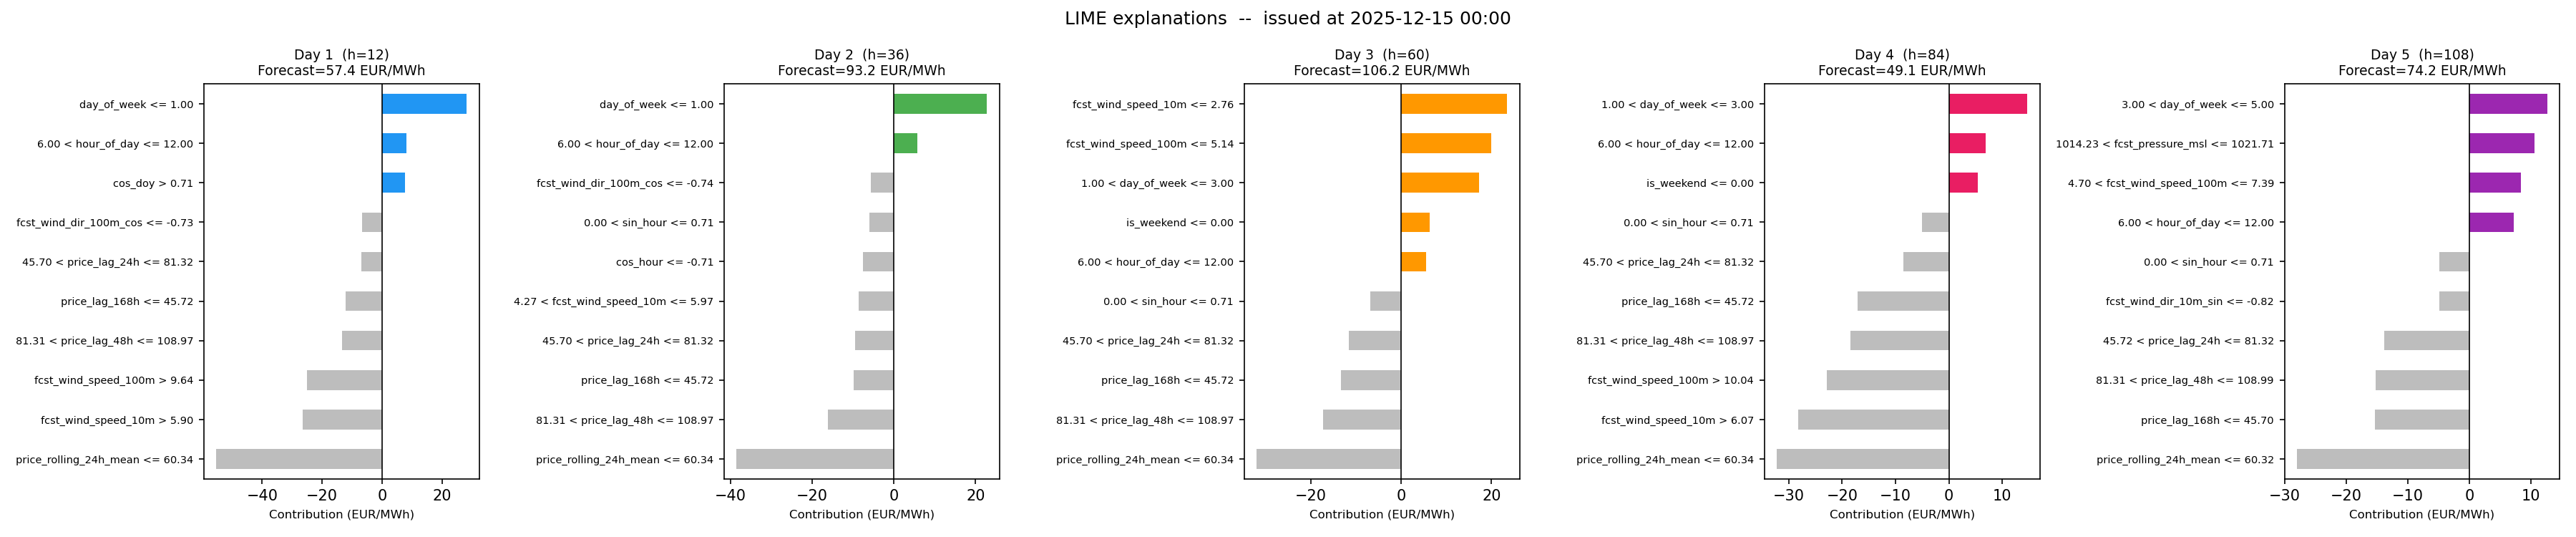

In [ ]:
plot_lime_explanations(width=1200)

LIME complements SHAP by focusing on one concrete forecast issue time. It fits a simple local surrogate around the selected forecast instance and shows which features pushed that specific prediction upward or downward. In other words, SHAP answers **"what generally drives this model?"**, while LIME helps answer **"why did the model make this recommendation now?"**

This local view is important for a consumer recommendation system because the same global model can produce different advice on different days. On one day, the recommended cheap window may be explained by strong wind and low recent prices. On another, a warning to consume earlier may be explained by lower renewable availability, higher lagged prices, and a peak-hour calendar effect.

The dashboard uses this idea in a deliberately narrow way. It does not send LIME explanations for all 120 forecast hours. Instead, it identifies the cheapest rolling 3-hour window and the most expensive rolling 3-hour window, then explains one representative hour inside each window. This keeps local Explainable AI focused on the actual decision points: when to shift flexible demand, and when to avoid consumption.


In [ ]:
dashboard_lime_context = make_dashboard_lime_summary(final_models, top_n=4)
dashboard_lime_context[
    [
        "window_label",
        "window_start",
        "window_end",
        "window_avg_dkk_kwh",
        "representative_time",
        "horizon_h",
        "feature_rule",
        "direction",
        "contribution_dkk_kwh",
    ]
].style.format(
    {
        "window_start": lambda x: x.strftime("%a %d %b %H:%M"),
        "window_end": lambda x: x.strftime("%a %d %b %H:%M"),
        "window_avg_dkk_kwh": "{:.3f}",
        "representative_time": lambda x: x.strftime("%a %d %b %H:%M"),
        "contribution_dkk_kwh": "{:+.4f}",
    }
)


,window_label,window_start,window_end,window_avg_dkk_kwh,representative_time,horizon_h,feature_rule,direction,contribution_dkk_kwh
0,Cheapest selected window,Sat 11 Apr 13:00,Sat 11 Apr 16:00,0.017,Sat 11 Apr 14:00,98,60.91 < Recent 24h price average <= 87.96,lowers forecast,-0.2116
1,Cheapest selected window,Sat 11 Apr 13:00,Sat 11 Apr 16:00,0.017,Sat 11 Apr 14:00,98,Forecast wind speed 10m > 6.16,lowers forecast,-0.1649
2,Cheapest selected window,Sat 11 Apr 13:00,Sat 11 Apr 16:00,0.017,Sat 11 Apr 14:00,98,47.12 < Price 168h ago <= 81.60,lowers forecast,-0.1628
3,Cheapest selected window,Sat 11 Apr 13:00,Sat 11 Apr 16:00,0.017,Sat 11 Apr 14:00,98,Day-of-year cycle sine > 0.75,lowers forecast,-0.1243
4,Most expensive selected window,Tue 07 Apr 19:00,Tue 07 Apr 22:00,0.875,Tue 07 Apr 20:00,8,60.29 < Recent 24h price average <= 87.50,lowers forecast,-0.3211
5,Most expensive selected window,Tue 07 Apr 19:00,Tue 07 Apr 22:00,0.875,Tue 07 Apr 20:00,8,Forecast wind speed 10m <= 2.84,raises forecast,+0.1620
6,Most expensive selected window,Tue 07 Apr 19:00,Tue 07 Apr 22:00,0.875,Tue 07 Apr 20:00,8,Price 48h ago <= 45.72,lowers forecast,-0.1359
7,Most expensive selected window,Tue 07 Apr 19:00,Tue 07 Apr 22:00,0.875,Tue 07 Apr 20:00,8,Day of week <= 1.00,raises forecast,+0.1154


The table above mirrors the local LIME information passed to the dashboard LLM. Each row is one local contribution for a representative forecast hour inside either the selected cheap window or the selected expensive window. Positive contributions raise the local price forecast; negative contributions lower it. This is why LIME is useful for the dashboard's household guidance: it can explain why the current recommendation window looks cheap or risky without flooding the prompt with attribution values for every hour.

The dashboard computes this local attribution with `final_day_models.joblib` and matching rows from `data/model_dataset.parquet`. For historical issue dates from the walk-forward prediction file, the LIME values should therefore be read as a local diagnostic for the final model family, not as a perfect audit trail of the exact fold model that produced every stored prediction. This is another reason the LLM receives the diagnostics as secondary evidence rather than as the sole explanation.

This also matters for the final impact analysis. The shifting simulation estimates what happens when households react to forecast-based recommendations. Explainable AI does not prove that the behavioral impact will occur, but it makes the mechanism more credible: the simulated shifts are based on price signals that can be inspected and related back to recognizable market drivers. If the impact model shows large benefits while SHAP or LIME reveals that the forecast signal is driven by an implausible artifact, that would be a warning sign before interpreting the resilience contribution.


## User dashboard: Household Recommendations

Forecasts alone are not enough for most households. A table of predicted prices is technically useful, but it does not automatically answer the practical question: **Should I run this flexible load now or later?**

The Streamlit dashboard in `dashboard.py` translates the 120-hour forecast state into daily outlooks, cheap windows, historical context, and household-oriented advice. The XAI outputs from the previous section support this step by making the forecast more inspectable: feature importance and SHAP are shown as model insight panels, while LIME-style local explanations can be used to audit individual recommendations when the model suggests waiting, consuming earlier, or shifting demand into a cheaper period.


In [ ]:
from src.analysis.forecast_analysis import preview_recommendation_workflow  # placeholder

preview_recommendation_workflow()


This step connects analytics to behavior. The recommendation does not require the household to understand residual uncertainty, XGBoost, or electricity-market dynamics. Instead, it communicates whether waiting is expected to be valuable and whether an upcoming period looks unusually expensive.

For a real deployment, the forecast table would be produced by the trained price model. In this notebook draft, the same recommendation functions are demonstrated with a forecast-like table so the logic is visible and easy to inspect.

## Modelling of impact: Rolling 120 hour energy shift heuristic

This section connects the forecasting and recommendation components directly to the resilience question. The objective is not only to assess how households potentially respond to price signals, but also to evaluate whether such responses meaningfully change the timing of demand in a way that reduces grid stress

To answer this, the project develops an impact-modelling framework that simulates how households may adjust their electricity consumption in response to forecast-guided recommendations. The simulated behavioural response is then used to adjust system level consumption loads. By comparing the original and adjusted load profiles, the framework assesses how the recommendation system could affect grid stress. These simulations therefore form the core basis for evaluating the potential resilience contribution of the project

### Energy shift heuristic
As illustrated in the figure below, the impact is driven by many decentralised decisions made by households under uncertainty, constraints, and flexibility limits. Modelling such behaviour exactly would require detailed knowledge of user preferences, appliance availability, and real-time decision-making.

A heuristic approach is therefore appropriate, as it provides a **structured and transparent approximation of behaviour** under realistic constraints. Rather than assuming perfect optimisation, the heuristic captures key behavioural mechanisms:
- Households respond to **price signals**
- They are limited by **waiting times and flexibility constraints**
- They cannot shift all demand and must respect **capacity limits**

The heuristic thus represents a **bounded rational decision process**, where households shift consumption when it is beneficial, but only within realistic limits. This makes it well-suited for estimating system-level impact while maintaining interpretability and control over assumptions.

![Illustration of the rolling 120-hour energy shift heuristic](ABA_heuristic_illustration.png)



The figure outlines a **Step-by-step simulation of behaviour** on how the heuristic is applied across the simulation horizon to model household behaviour dynamically.

1. **Select issue times**  
   The simulation starts by selecting decision points where forecasts and recommendations are generated.

2. **Build a 120-hour window**  
   For each issue time, the model considers the next 120 hours of forecasted prices and actual system load. This defines the decision horizon available to the household.

3. **Create baseline and segments**  
   The household share is separated from the total system load and divided into behavioural segments: inflexible demand, wet loads, thermal demand, and EV charging.  
   Each segment is assigned a demand share, a maximum shiftable share, and a maximum waiting time.

4. **Evaluate candidate hours**  
   For each hour and each flexible segment, the model compares the current hour with future candidate hours inside the allowed waiting window.  
   Candidate hours with lower forecasted prices receive better scores, while longer waiting times are penalised.

5. **Shift energy subject to constraints**  
   If a future hour has a better score than the current hour, part of the flexible load is shifted to that hour.  
   The shift is only accepted if it respects the segment capacity, maximum waiting time, and maximum shiftable share.

6. **Repeat hour by hour**  
   The process is repeated sequentially across the 120-hour window. Over time, many small shifting decisions accumulate into a modified household and system load profile.

7. **Measure resilience impact**  
   The shifted load profile is compared with the baseline load profile. The resilience effect is measured by how much cumulative load above the historical p95 peak threshold is reduced.

### 90-day simulation of shifted consumption

After the heuristic is defined, we simulate its effect hour for hour. For each selected issue time, the model decides what flexible energy to keep, what to move out of the current hour, and where to place it within the next 120 hours. The outputs are shifted household load, shifted system load, realized energy movement, and cost-based summary metrics.

To keep the impact section aligned with the forecasting evaluation, the simulation is run over the last 90 days. This is the same time span used as the final forecast test period. Because each forecast covers five days, we use non-overlapping 120-hour windows so that the 90-day impact estimate is not double-counting the same hours.

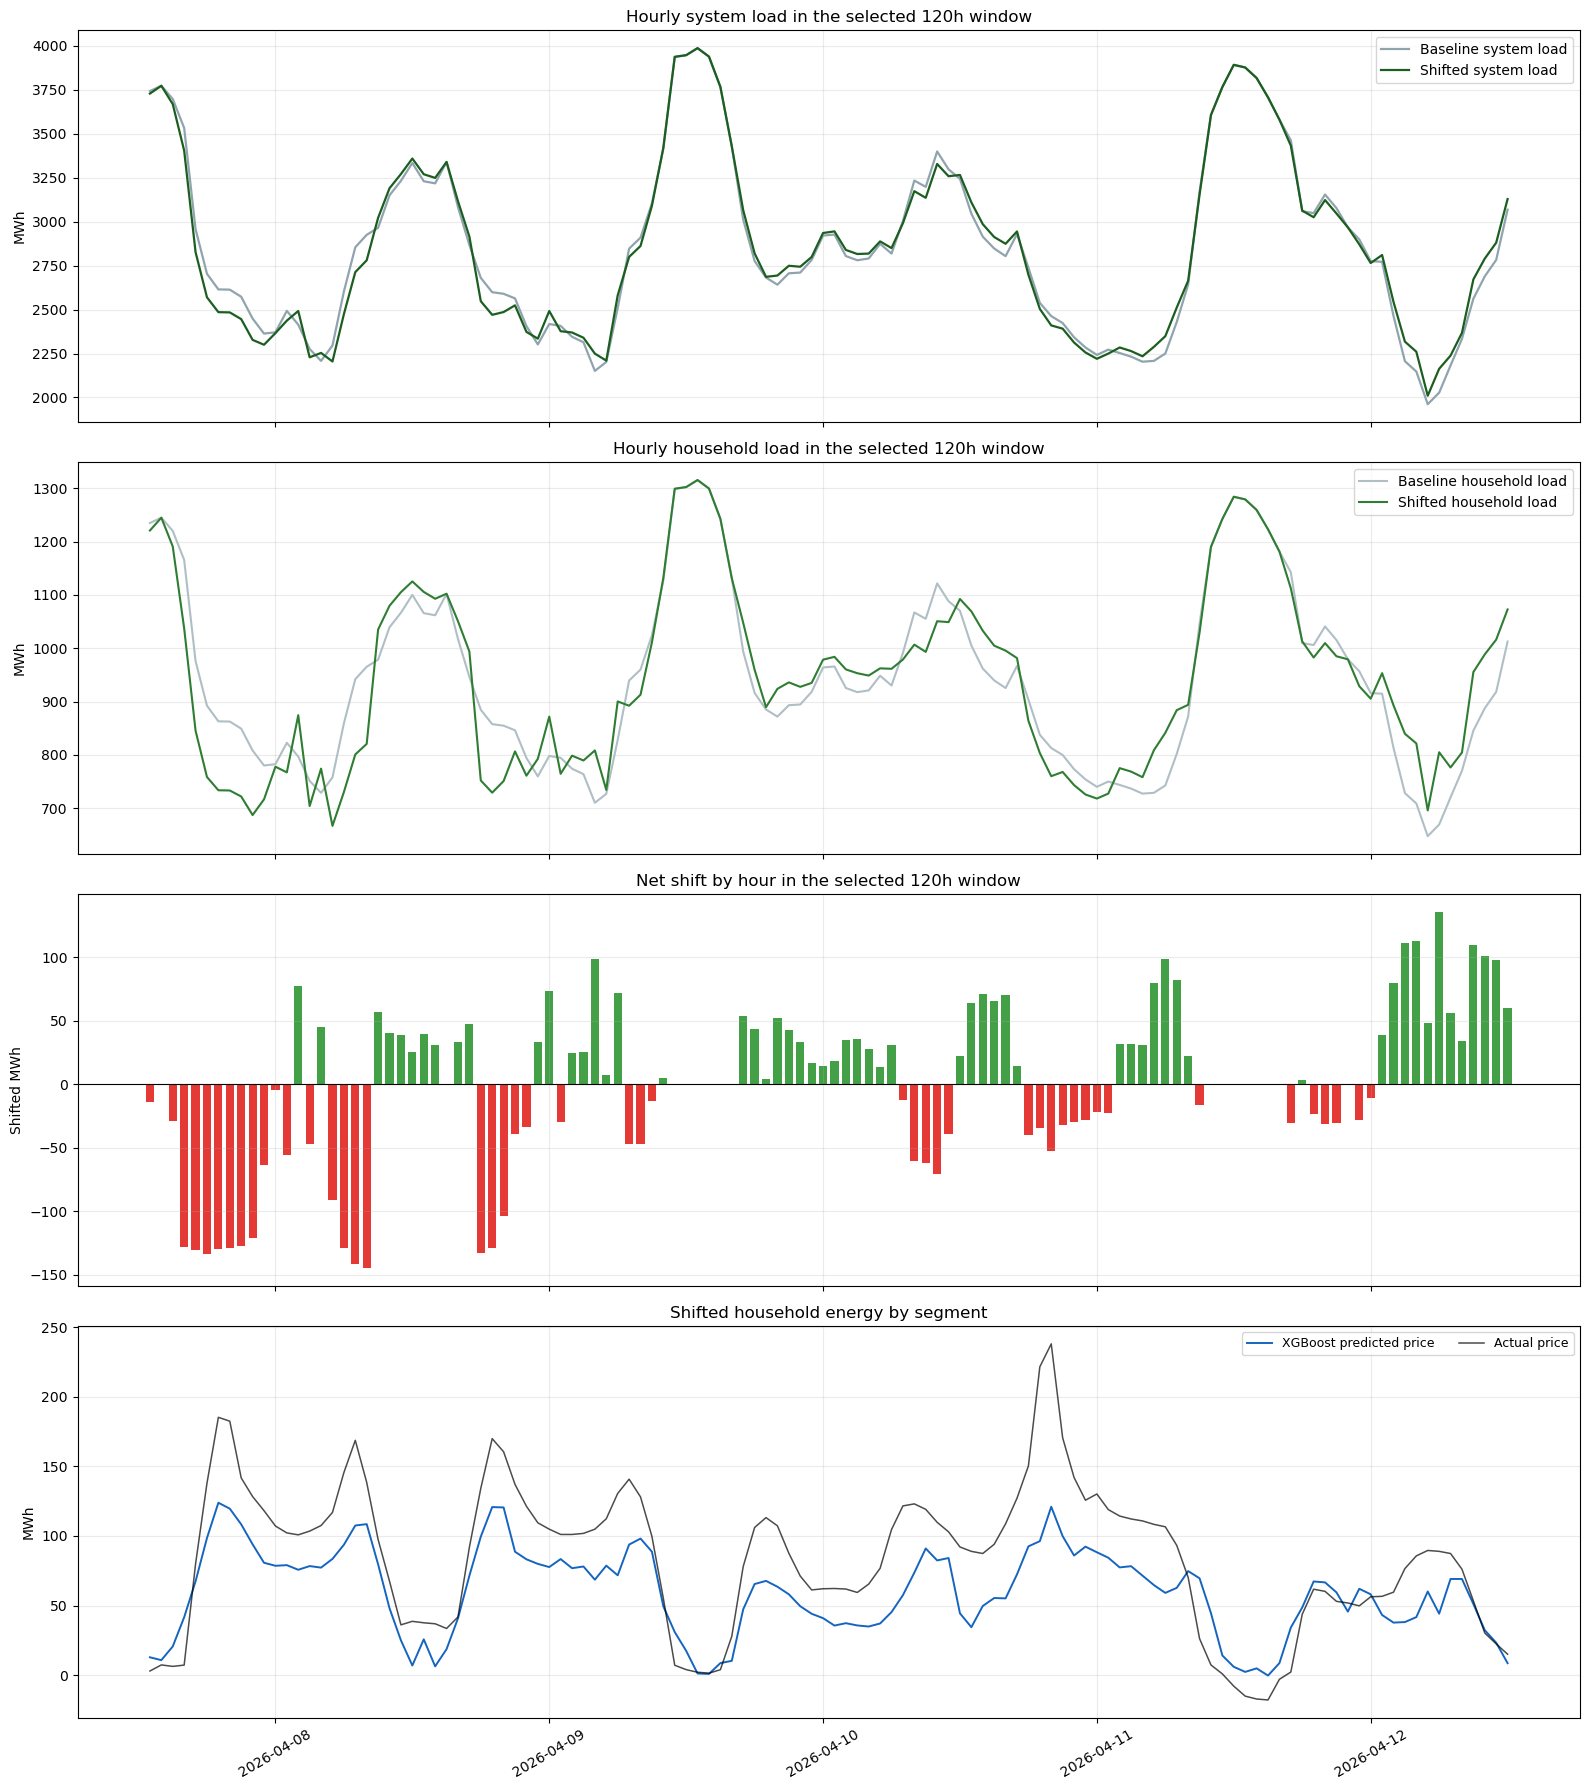

In [ ]:
from src.analysis.impact_analysis import run_granular_shift_illustration

granular_result = run_granular_shift_illustration()

The four plots collectively illustrate how forecast-driven household behavior translates into measurable, but constrained, resilience improvements.

At the system and household load level (top two plots), the shifted profiles closely follow the baseline shape, confirming that total energy is preserved. The impact is therefore not a structural change in demand, but a temporal redistribution. The most visible effect occurs around peak periods, where the shifted load is slightly reduced and redistributed to adjacent hours. This demonstrates that the method successfully targets high-stress periods, but only partially flattens them.

The net shift plot (third panel) makes the behavioral mechanism explicit. Negative values (red) coincide with high-load periods, indicating that consumption is actively moved away from peaks, while positive values (green) appear in lower-load periods, where energy is reallocated. This reflects the intended optimization: households delay or advance flexible consumption within the allowed waiting window. The clustering of shifts suggests that behavior is not continuous, but occurs in discrete, opportunistic adjustments when favorable alternatives exist.

The price context (bottom plot) explains why these shifts occur. Periods with high actual and predicted prices align with negative shifts, confirming that households respond to price signals as intended. Conversely, periods with low or moderate prices show little or no shifting—even when system load is relatively high. This reveals a key behavioral constraint: shifting is driven by economic incentives, not directly by grid need.

**The central insight on resilience impact:**
The method improves resilience by aligning flexible demand with price signals, which indirectly reduces pressure during some peak periods. However, the effect is selective rather than comprehensive. Peaks are reduced where price signals are strong, but persist where prices fail to reflect system stress. As a result, resilience gains are visible but moderate. The system benefits from smoother load profiles and reduced peak intensity, yet the remaining peaks highlight that price-based demand shifting alone cannot fully resolve grid pressure.


#### Behavior patterns across days and hours
While the previous figures illustrate how shifting reduces peak pressure within a specific time window, it is equally important to understand whether these effects follow systematic temporal patterns. The following heatmap aggregates the net shift across the full evaluation period by hour of day and day of week. This provides insight into when shifting occurs on average, and whether the heuristic consistently responds to recurring price signals rather than isolated events.


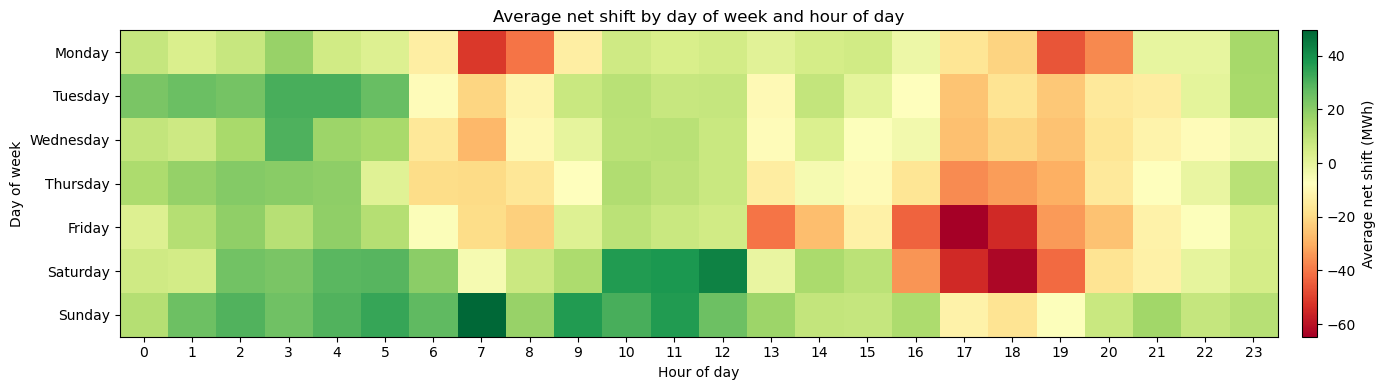

In [8]:
from src.analysis.impact_analysis import (
    plot_average_net_shift_heatmap,
    run_90_day_impact_simulation,
)

impact_90d = run_90_day_impact_simulation(simulation_days=90)
heatmap_df, _, _ = plot_average_net_shift_heatmap(impact_90d["profiles"])


The heatmap reveals a clear and structured pattern in shifting behavior, which supports both the validity of the heuristic and its contribution to resilience.

First, a consistent morning inflow of energy (green) is observed, particularly in the early hours (around 02:00–06:00) and again mid-morning. These periods typically correspond to lower electricity prices, indicating that the model systematically reallocates demand toward hours with favorable system conditions. In contrast, evening hours (approximately 17:00–20:00) show strong negative shifts (red), especially toward the end of the week. These hours coincide with well-known peak demand periods, where both consumption and prices tend to be high. The model therefore successfully identifies and avoids structurally stressed periods, rather than reacting randomly. This pattern is particularly pronounced on Fridays and Saturdays, where evening peaks are both larger and more consistently reduced. This suggests that the heuristic captures not only hourly dynamics but also weekly behavioral and price structures, which strengthens confidence in its general applicability.

**From a resilience perspective**, this is important because it shows that the model contributes to predictable and repeatable load smoothing, rather than ad hoc adjustments. By consistently shifting demand away from recurring peak periods, the method helps reduce systemic stress in the hours where the grid is most vulnerable. At the same time, the heatmap also highlights limitations. Not all peak periods are fully mitigated, and some hours show only modest or no shifting. This indicates that the heuristic is constrained by the availability of economically attractive alternatives and the imposed waiting-time limits.

#### Overall simulated impact:
The heatmap demonstrated that the shifting heuristic produces consistent and structured behavioral patterns across hours and days, systematically moving demand away from recurring peak periods. However, while these temporal patterns validate how the model behaves, they do not directly quantify how much this behavior contributes to resilience. To assess the overall system-level impact, the following figure aggregates the effect across the full 90-day horizon, measuring the reduction in load above the historical p95 threshold.


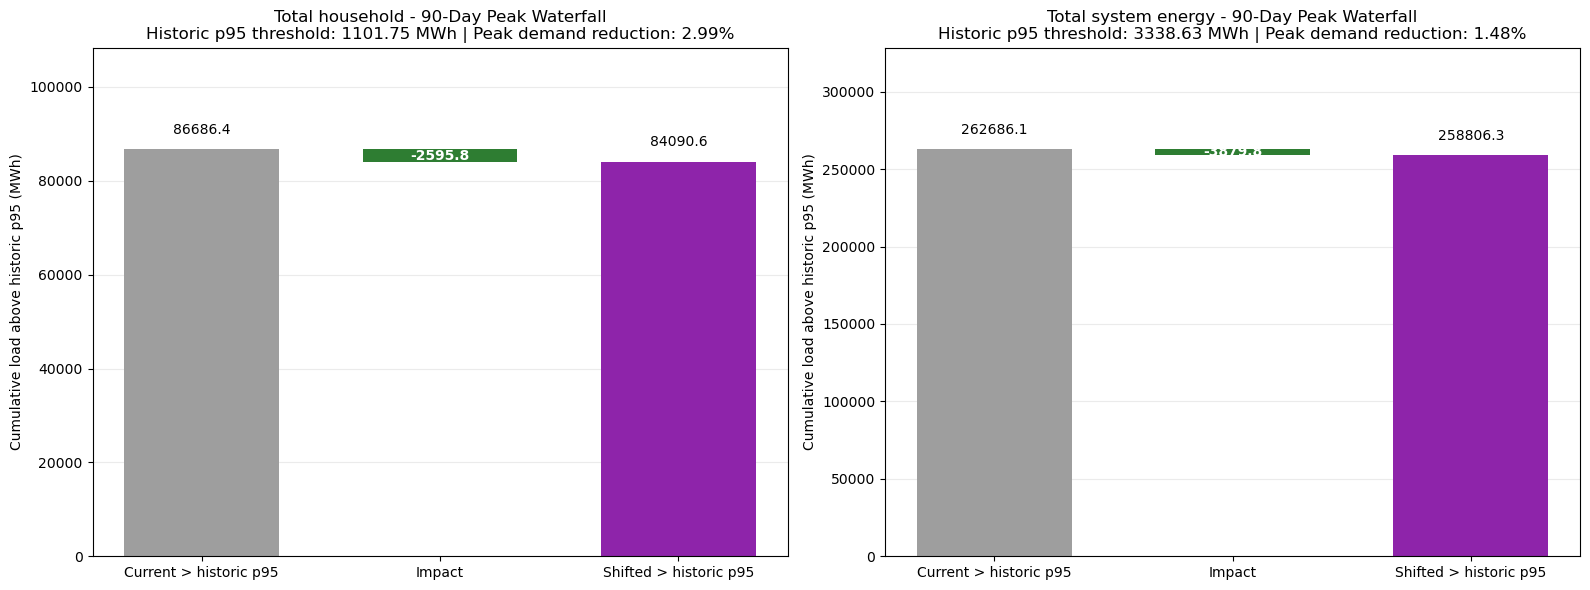

In [9]:
from src.analysis.impact_analysis import plot_peak_excess_waterfalls

peak_summary_df, _, _ = plot_peak_excess_waterfalls(
    impact_90d["profiles"],
    impact_90d["system_load"],
)


At the household level, the model reduces cumulative load above the p95 threshold by 3.01%, corresponding to a reduction of approximately 2,614 MWh. This confirms that forecast-guided shifting successfully targets the most extreme consumption periods and redistributes a meaningful share of flexible demand.

At the system level, the corresponding reduction is 1.48%, reflecting that households represent only a fraction of total demand. While smaller in relative terms, this result is important: it demonstrates that **local behavioral adjustments can scale to system-level effects, even when applied to a limited share of consumption.**

Importantly, the waterfall structure highlights that the reduction is achieved without lowering total energy consumption. The impact arises purely from reducing the magnitude and duration of peak exceedances, rather than eliminating demand. This reinforces the interpretation of the method as a load-shaping mechanism rather than a demand-reduction strategy.

**From a resilience perspective**, this reduction implies that the system spends less time in its most stressed operating regime. Even moderate reductions in peak pressure can improve system stability, reduce the need for costly balancing actions, and enable better integration of renewable energy.


### Assumptions behind the heuristic

The impact modelling relies on a set of explicit assumptions that define how much and how flexibly household demand can respond to price signals. These assumptions primarily act as modelling parameters, specifying the household share of system demand, the segmentation of consumption, the maximum shiftable shares, and the allowed waiting times.

The values used are informed by existing literature on household electricity consumption and demand-side flexibility, and are chosen to reflect a realistic and conservative representation of household behavior in energy systems. At the same time, they should not be interpreted as exact behavioral truths, but rather as scenario-based approximations that enable structured analysis.

Importantly, the assumptions extend beyond numerical parameters. They also include modelling choices about behavior, such as how households trade off price savings against waiting time, and how decisions are made within constrained flexibility windows. These choices define the decision logic of the heuristic and therefore directly shape the resulting system impact.

As such, the impact model should be understood as a proof-of-concept framework, where the purpose is not to perfectly predict real-world behavior, but to test whether forecast-guided demand shifting can plausibly contribute to system resilience under realistic constraints.


In [1]:
from src.analysis.impact_analysis import display_heuristic_assumption_tables

display_heuristic_assumption_tables()

| Assumption | Value |
|---|---:|
| Household share of total system load | 33.0% |
| Flexible share of household load | 40.0% |
| Maximum theoretical shiftable share of household load | 15.0% |
| Maximum theoretical shiftable share of total system load | 5.0% |

| Segment | Share of household load | Max shiftable share within segment | Max shiftable share of household load | Max wait | Wait penalty |
|---|---:|---:|---:|---:|---:|
| Inflexible load | 60.0% | 0.0% | 0.0% | 0 h | 0.00 |
| Wet loads | 10.0% | 35.0% | 3.5% | 48 h | 0.90 |
| Thermal load | 20.0% | 15.0% | 3.0% | 24 h | 1.20 |
| EV charging | 10.0% | 85.0% | 8.5% | 120 h | 0.35 |

The tables highlight that the model is intentionally conservative in its representation of flexibility. A substantial share of household demand is assumed to be inflexible, and even within flexible segments, only a limited portion can be shifted.

Flexibility is unevenly distributed across segments. EV charging exhibits the highest degree of flexibility, with both a large shiftable share and a long waiting window, while wet loads and thermal demand are more constrained. This reflects realistic differences in how long different energy services can be delayed without affecting user comfort.

The assumptions also embed a behavioral structure through the waiting-time penalties. These penalties reflect that households do not optimize purely for price, but balance cost savings against inconvenience. As a result, the model captures a form of bounded rationality, where shifting occurs only when it is sufficiently attractive relative to the required delay.

Together, these assumptions define the feasible action space of the heuristic. They determine when shifting is possible, how far it can occur in time, and how much energy can be moved. Changing these parameters would therefore directly alter the magnitude and timing of the simulated impact.


**These assumptions play a central role in interpreting the results of the impact simulation.** On one hand, the conservative setup strengthens the credibility of the findings: if measurable peak reduction is achieved under limited flexibility, it suggests that the mechanism is robust.

On the other hand, the assumptions also define the upper bound of the estimated impact. The model does not explore the full theoretical flexibility of the system, but rather a constrained and realistic subset. This means that the reported results likely represent a lower-bound estimate of what could be achieved under higher flexibility adoption or stronger behavioral incentives.

More broadly, the assumptions highlight that the resilience impact is not only a function of the forecasting model, but equally a function of how behavior is modelled. The simulation therefore reflects an interaction between price signals, behavioral response, and structural constraints, rather than a purely technical optimization outcome.


## Discussion of resilience impact and limitation to the approach
The project shows that intelligent methods can contribute to grid resilience by turning price forecasts into actionable energy recommendation that causes household energy shifts. **The evidence suggests a measurable but moderate reduction in peak pressure of 3% on the household energy grid of a 90-day horizon.** The main insight is therefore not that household shifting alone solves grid congestion, but that price forecasting and explainable energy recommendations can become one layer in a broader resilience strategy. Stronger results would require real behavioral validation, local grid constraints, richer forecast inputs, and optimization that explicitly balances household comfort, cost savings, and system-level resilience.

The disruption considered in this project is the increasing pressure on the electricity system caused by rising demand and a larger share of variable renewable energy. Since direct grid congestion data was not available, historical system consumption was used as a proxy for grid stress, with hours above the historical p95 threshold interpreted as peak-pressure periods. The proposed solution combines an XGBoost price forecasting model, uncertainty bands, explainable AI methods, and a household shifting heuristic. The forecasting model predicts hourly prices up to 120 hours ahead, while SHAP and LIME are used to inspect whether the forecast signal is driven by plausible market factors. The shifting heuristic then simulates how flexible household demand could be moved away from expensive and stressed hours.
The main evidence is the 90-day impact simulation. In the central scenario, the model reduces household peak excess by 3.01% and total system peak excess by 1.48%. This supports the resilience argument: even when only a limited share of demand is flexible, forecast-guided household behavior can reduce pressure in the most stressed hours. The result is therefore not only a cost-saving result for households, but also a system-level contribution to resilience.

**A key limitation of the results is that household behavior is modelled and simulated rather than empirically observed.** The behavioral model assumes that households respond to a combination of price-based recommendations and a waiting-time penalty, which provides a tractable approximation of flexibility. However, real household behavior is influenced by a broader set of factors, including comfort preferences, daily routines, appliance constraints, and trust in automated recommendations. These aspects are not explicitly captured and may reduce the willingness or ability to shift consumption, implying that the estimated impact is likely overstated. At the same time, the modelling framework omits certain behaviors that could increase flexibility. In particular, the model does not account for anticipatory actions such as frontloading consumption - for example, charging an electric vehicle in the current hour if prices are expected to increase over the forecast horizon. Incorporating such forward-looking behavior could lead to additional load redistribution and potentially amplify the estimated impact. Overall, behavioral modelling introduces both upward and downward biases, depending on which mechanisms are included or excluded. This highlights that simulation-based results should be interpreted as indicative rather than definitive. A field experiment or real-world deployment would provide stronger evidence of actual adoption patterns and enable a more reliable assessment of the true resilience impact.

A second limitation is that grid stress is approximated using total system consumption. This is transparent and measurable, but it does not capture local congestion, transformer constraints, or distribution-level bottlenecks. In reality, shifting demand away from a national peak does not always reduce pressure at the exact location where the grid is constrained. With access to local grid data, the model could optimize for actual congestion points rather than system-wide load. This might produce a smaller but more operationally meaningful resilience effect.

A third limitation is the shifting heuristic itself. It uses predefined segment shares, waiting limits, and shiftable fractions for inflexible demand, wet loads, thermal load, and EV charging. These assumptions make the model understandable and conservative, but they also determine the ceiling of the estimated impact. If EV adoption or smart-appliance participation increases, the resilience effect could become larger. Conversely, if users are less willing to wait than assumed, the effect would be smaller. A sensitivity analysis across behavioral assumptions would therefore strengthen the discussion of robustness.

The forecast model also has limitations. XGBoost is suitable for nonlinear tabular forecasting and supports explainability, but the model still depends on the available predictors. Limited weather, demand, and market features may prevent the model from capturing all price drivers. In addition, the impact simulation depends on forecasted prices, so forecast errors can directly affect the quality of the shifting decisions. The uncertainty bands partly address this issue, but a more robust version could optimize decisions under uncertainty instead of using point forecasts as the main input.

The findings suggest that price forecasting and explainable energy recommendations is a viable component of a broader resilience strategy, but its effectiveness depends on real-world adoption, richer data, and integration with system-level optimization.


## Conclusion

This project addressed the challenge of increasing pressure in the DK1 electricity system driven by rising demand and variable renewable energy. The central question was whether price forecasting combined with explainable energy recommendations can reduce peak load and improve system resilience.

To answer this, an integrated approach was developed, combining XGBoost-based price forecasting, uncertainty estimation, explainable AI, and a 120-hour household shifting heuristic. The method was evaluated over a 90-day test period, where forecast-guided demand shifting reduced household peak excess by 3.01% and total system peak excess by 1.48%.

These results demonstrate that intelligent, data-driven methods can contribute to resilience by enabling households to adjust consumption in response to anticipated grid stress. However, the impact is moderate and should be interpreted as indicative rather than definitive. Key limitations include the reliance on simulated household behavior, the use of system-level consumption as a proxy for grid stress, and assumptions embedded in both the shifting heuristic and forecasting model.

The findings suggest that price forecasting and explainable energy recommendations is a viable component of a broader resilience strategy, but its effectiveness depends on real-world adoption, richer data, and integration with system-level optimization.

